In [121]:
# %%

import numpy as np
import matplotlib.pyplot as plt
import h5py
from units import pressure, mu, KELVIN, CONST_kB, CONST_amu, unit_q, unit_time, unit_density, unit_length
import skspatial.objects as so


def read_hdf5(filename=None):
    if filename is None:
        filename = (
            # "/home/mpaadmin/files/data/Rlsh_1000_res_256_M_0.5_hydro/Turb.out2.00650.athdf"
             "/ptmp/mpa/ankitad/athenapk/sim_nocool_gpu/parthenon.prim.00000.phdf"
            #"/ptmp/mpa/ankitad/athenapk/sim_run1/parthenon.prim.00017.phdf"
            # "/home/mpaadmin/files/data/Rlsh_1000_res_256_M_0.5_beta_100/Turb.out2.00650.athdf"
        )

    with h5py.File(filename, "r") as f:
        print(f"Keys: {f.keys()} \n")
        print(f"Attributes: {f.attrs.keys()} \n")

        prim = f["prim"][()]
        rho = prim[:, 0]
        prs = prim[:, 4]  
        print("this is rho shape", rho.shape[0])
        # vel1 = prim[2]
        # vel2 = prim[3]
        # vel3 = prim[4]

        # x1 = f["x1v"][()]
        # x2 = f["x2v"][()]
        # x3 = f["x3v"][()]

        LogicalLocations = f["LogicalLocations"][()]
        MeshBlockSize = np.array(rho.shape[1:4])     # auto-detect (32, 32, 32)
        NumMeshBlocks = rho.shape[0]
        RootGridSize = np.array([128, 128, 128])
    
        print("np.shape(LogicalLocations) =", np.shape(LogicalLocations))
        print("np.shape(rho) =", np.shape(rho))
        #print("MeshBlockSize =", MeshBlockSize)
        print("RootGridSize =", RootGridSize)
        print("NumMeshBlocks =", NumMeshBlocks)
        print("LogicalLocations[10] =", LogicalLocations[5])

        # print(f"{np.shape(x1) = }")
        # print(f"{np.shape(x2) = }")
        # print(f"{np.shape(x3) = }\n")
        '''
        MeshBlockSize = f.attrs["MeshBlockSize"]
        print(f"{MeshBlockSize = }")

        RootGridSize = f.attrs["RootGridSize"]
        print(f"{RootGridSize = }")

        NumMeshBlocks = f.attrs["NumMeshBlocks"]
        print(f"{NumMeshBlocks = }")
        '''
    #print(f"{LogicalLocations[10] = }")

    rho_full = np.zeros(tuple(RootGridSize), dtype=float)
    prs_full = np.zeros(tuple(RootGridSize), dtype=float)

    # x1_full = np.zeros(np.product(np.shape(x1)), dtype=float)
    # x2_full = np.zeros(np.product(np.shape(x2)), dtype=float)
    # x3_full = np.zeros(np.product(np.shape(x3)), dtype=float)

    for i in range(NumMeshBlocks):
        start1 = MeshBlockSize[0] * LogicalLocations[i][0]
        end1 = start1 + MeshBlockSize[0]

        start2 = MeshBlockSize[1] * LogicalLocations[i][1]
        end2 = start2 + MeshBlockSize[1]

        start3 = MeshBlockSize[2] * LogicalLocations[i][2]
        end3 = start3 + MeshBlockSize[2]

        rho_full[start3:end3, start2:end2, start1:end1] = rho[i]

        prs_full[start3:end3, start2:end2, start1:end1] = prs[i]

    #     x1_full[start1:end1] = x1[i]
    #     x2_full[start2:end2] = x2[i]
    #     x3_full[start3:end3] = x3[i]

    # T = prs_full / rho_full

    return rho_full, prs_full

In [122]:
print(read_hdf5())


Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

this is rho shape 64
np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 32, 32, 32)
RootGridSize = [128 128 128]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]
(array([[[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,

Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

this is rho shape 64
np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 32, 32, 32)
RootGridSize = [128 128 128]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]


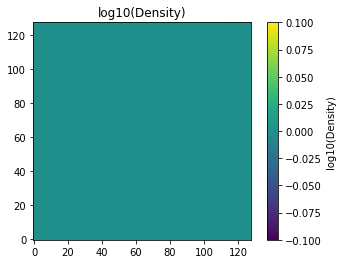

In [123]:
# Call the data loader
rho_full, prs_full = read_hdf5()

# Visualize a midplane slice
def show_midplane_slice(data, label):

    plt.imshow(data[:, :, data.shape[2] // 2], origin='lower')
    plt.title(label)
    
    plt.colorbar(label=label)
    plt.show()

rho_safe = np.where(rho_full <= 0, 1e-20, rho_full)
log_rho = np.log10(rho_safe)
show_midplane_slice(log_rho, "log10(Density)")



In [124]:
# Load and compute
rho_full, prs_full = read_hdf5()
rho_flat = rho_full.flatten()
prs_flat = prs_full.flatten()

# Avoid division by zero
rho_safe = np.where(rho_flat == 0, 1e-20, rho_flat)
T_flat = (prs_flat / rho_safe) * (KELVIN * mu)


Keys: <KeysViewHDF5 ['Blocks', 'Info', 'Input', 'Levels', 'Locations', 'LogicalLocations', 'Params', 'VolumeLocations', 'acc', 'prim', 'tracers']> 

Attributes: <KeysViewHDF5 []> 

this is rho shape 64
np.shape(LogicalLocations) = (64, 3)
np.shape(rho) = (64, 32, 32, 32)
RootGridSize = [128 128 128]
NumMeshBlocks = 64
LogicalLocations[10] = [1 0 1]


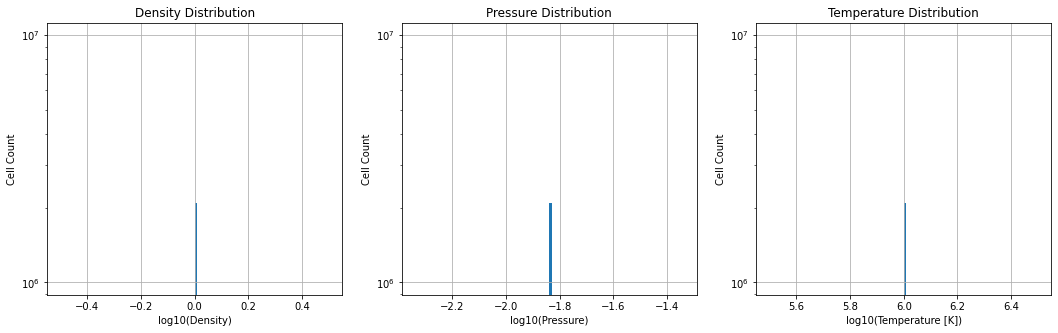

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].hist(np.log10(rho_safe), bins=100, log=True)
axs[0].set_xlabel("log10(Density)")
axs[0].set_ylabel("Cell Count")
axs[0].set_title("Density Distribution")
axs[0].grid(True)

prs_safe = np.where(prs_flat <= 0, 1e-20, prs_flat)
axs[1].hist(np.log10(prs_safe), bins=100, log=True)
axs[1].set_xlabel("log10(Pressure)")
axs[1].set_ylabel("Cell Count")
axs[1].set_title("Pressure Distribution")
axs[1].grid(True)


T_safe = np.where(T_flat <= 0, 1e-20, T_flat)
axs[2].hist(np.log10(T_safe), bins=100, log=True)
axs[2].set_xlabel("log10(Temperature [K])")
axs[2].set_ylabel("Cell Count")
axs[2].set_title("Temperature Distribution")
axs[2].grid(True)



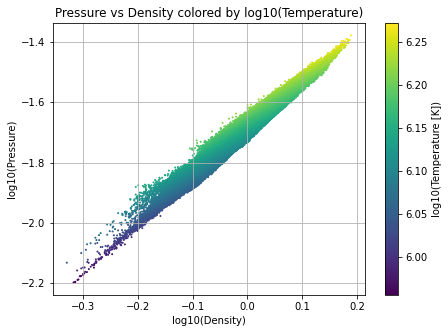

In [102]:

# Plot 4: Pressure vs Density (log-log) colored by log T
plt.figure(figsize=(7, 5))
sc = plt.scatter(np.log10(rho_safe), np.log10(prs_safe), c=np.log10(T_safe), s=1, cmap='viridis')
plt.xlabel("log10(Density)")
plt.ylabel("log10(Pressure)")
plt.title("Pressure vs Density colored by log10(Temperature)")
plt.colorbar(sc, label="log10(Temperature [K])")
plt.grid(True)
plt.show()


HST headers: ['time', 'dt', 'cycle', 'nbtotal', 'mass', '1-mom', '2-mom', '3-mom', 'KE', 'tot-E', 'Ms', 'DeltaEcool']


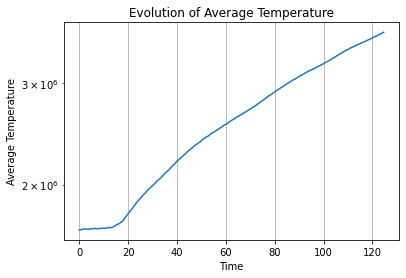

In [120]:


def read_hst_file(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    header_line = next(line for line in lines if line.startswith("# [1]"))
    headers = [entry.split('=')[1] for entry in header_line.strip('#').strip().split()]
    data = np.loadtxt(filename)
    return headers, data

hst_file = "/ptmp/mpa/ankitad/athenapk/sim_nocool_gpu/parthenon.out1.hst"
headers, data = read_hst_file(hst_file)

print("HST headers:", headers)

# Index map
time_idx = headers.index("time")
mass_idx = headers.index("mass")
ke_idx   = headers.index("KE")
etot_idx= headers.index("tot-E")

# Extract data
time = data[:, time_idx]
mass = data[:, mass_idx]
KE   = data[:, ke_idx]
Etot = data[:, etot_idx]

# Compute internal energy
Etherm = Etot - KE

# Average T ~ Etherm / mass (in code units)
#avg_T = (Etherm / mass) * (2 / 3) * ((mu*CONST_amu)/CONST_kB) * (unit_q * unit_time) * ((unit_density/ (unit_length)**3)**(-1)) # simple proportionality; constants absorbed
avg_T = (Etherm / mass) * (KELVIN) * (2/3)

# Plot
plt.plot(time, avg_T)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Average Temperature")
plt.title("Evolution of Average Temperature")
plt.grid(True)
plt.show()



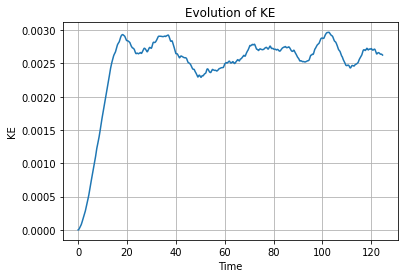

In [126]:
# plotting KE
plt.plot(time, KE)
plt.xlabel("Time")
plt.ylabel("KE")
plt.title("Evolution of KE")
plt.grid(True)
plt.show()

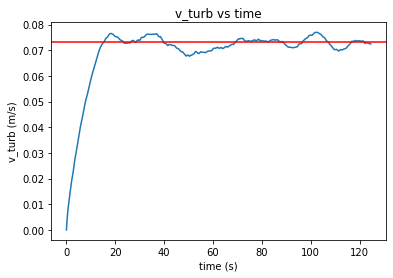

In [130]:
v_turb = np.sqrt(2* KE /mass)
plt.plot(time, v_turb)
plt.xlabel('time (s)')
plt.ylabel('v_turb (m/s)')
plt.axhline(np.average(v_turb[- 500 : ]), color='r', label='v_turb')
plt.title('v_turb vs time')
plt.show()

In [133]:
t_eddy = 0.5/np.average(v_turb[- 500 : ])
print("t_eddy = ", t_eddy)

t_eddy =  6.82739987175247


HST headers: ['time', 'dt', 'cycle', 'nbtotal', 'mass', '1-mom', '2-mom', '3-mom', 'KE', 'tot-E', 'Ms', 'DeltaEcool']


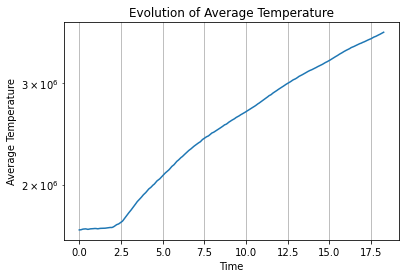

In [134]:


def read_hst_file(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    header_line = next(line for line in lines if line.startswith("# [1]"))
    headers = [entry.split('=')[1] for entry in header_line.strip('#').strip().split()]
    data = np.loadtxt(filename)
    return headers, data

hst_file = "/ptmp/mpa/ankitad/athenapk/sim_nocool_gpu/parthenon.out1.hst"
headers, data = read_hst_file(hst_file)

print("HST headers:", headers)

# Index map
time_idx = headers.index("time")
mass_idx = headers.index("mass")
ke_idx   = headers.index("KE")
etot_idx= headers.index("tot-E")

# Extract data
time = data[:, time_idx]
mass = data[:, mass_idx]
KE   = data[:, ke_idx]
Etot = data[:, etot_idx]

# Compute internal energy
Etherm = Etot - KE

# Average T ~ Etherm / mass (in code units)
#avg_T = (Etherm / mass) * (2 / 3) * ((mu*CONST_amu)/CONST_kB) * (unit_q * unit_time) * ((unit_density/ (unit_length)**3)**(-1)) # simple proportionality; constants absorbed
avg_T = (Etherm / mass) * (KELVIN) * (2/3)
time_e = time/t_eddy
# Plot
plt.plot(time_e, avg_T)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Average Temperature")
plt.title("Evolution of Average Temperature")
plt.grid(True)
plt.show()



HST headers: ['time', 'dt', 'cycle', 'nbtotal', 'mass', '1-mom', '2-mom', '3-mom', 'KE', 'tot-E', 'Ms', 'DeltaEcool']


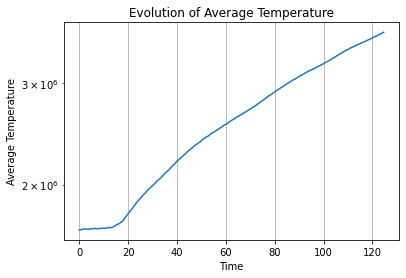

In [ ]:


def read_hst_file(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    header_line = next(line for line in lines if line.startswith("# [1]"))
    headers = [entry.split('=')[1] for entry in header_line.strip('#').strip().split()]
    data = np.loadtxt(filename)
    return headers, data

hst_file = "/ptmp/mpa/ankitad/athenapk/sim_nocool_gpu/parthenon.out1.hst"
headers, data = read_hst_file(hst_file)

print("HST headers:", headers)

# Index map
time_idx = headers.index("time")
mass_idx = headers.index("mass")
ke_idx   = headers.index("KE")
etot_idx= headers.index("tot-E")

# Extract data
time = data[:, time_idx]
mass = data[:, mass_idx]
KE   = data[:, ke_idx]
Etot = data[:, etot_idx]

# Compute internal energy
Etherm = Etot - KE

# Average T ~ Etherm / mass (in code units)
#avg_T = (Etherm / mass) * (2 / 3) * ((mu*CONST_amu)/CONST_kB) * (unit_q * unit_time) * ((unit_density/ (unit_length)**3)**(-1)) # simple proportionality; constants absorbed
avg_T = (Etherm / mass) * (KELVIN) * (2/3)

# Plot
plt.plot(time, avg_T)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Average Temperature")
plt.title("Evolution of Average Temperature")
plt.grid(True)
plt.show()



HST headers: ['time', 'dt', 'cycle', 'nbtotal', 'mass', '1-mom', '2-mom', '3-mom', 'KE', 'tot-E', 'Ms', 'DeltaEcool']


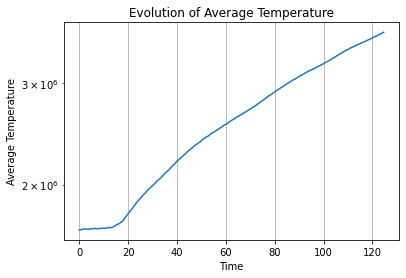

In [ ]:


def read_hst_file(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    header_line = next(line for line in lines if line.startswith("# [1]"))
    headers = [entry.split('=')[1] for entry in header_line.strip('#').strip().split()]
    data = np.loadtxt(filename)
    return headers, data

hst_file = "/ptmp/mpa/ankitad/athenapk/sim_nocool_gpu/parthenon.out1.hst"
headers, data = read_hst_file(hst_file)

print("HST headers:", headers)

# Index map
time_idx = headers.index("time")
mass_idx = headers.index("mass")
ke_idx   = headers.index("KE")
etot_idx= headers.index("tot-E")

# Extract data
time = data[:, time_idx]
mass = data[:, mass_idx]
KE   = data[:, ke_idx]
Etot = data[:, etot_idx]

# Compute internal energy
Etherm = Etot - KE

# Average T ~ Etherm / mass (in code units)
#avg_T = (Etherm / mass) * (2 / 3) * ((mu*CONST_amu)/CONST_kB) * (unit_q * unit_time) * ((unit_density/ (unit_length)**3)**(-1)) # simple proportionality; constants absorbed
avg_T = (Etherm / mass) * (KELVIN) * (2/3)

# Plot
plt.plot(time, avg_T)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Average Temperature")
plt.title("Evolution of Average Temperature")
plt.grid(True)
plt.show()

